# ⭐ Day 20: Seaborn Statistical Plots
Distributions & Correlations | Step-by-Step Tutorial with Examples & Exercises

*Day 20 of 369-day Python & AI Learning Path*

## Introduction

Welcome to Day 20 of your Python & AI Learning Path! Today we're diving deep into **Seaborn**, one of the most powerful and elegant data visualization libraries in the Python ecosystem.

Seaborn is built on top of Matplotlib and provides a high-level interface for drawing attractive and informative statistical graphics. While Matplotlib gives you fine-grained control over every pixel, Seaborn understands data structures and statistical relationships, allowing you to create complex visualizations with minimal code.

In AI and Machine Learning, **Exploratory Data Analysis (EDA)** is absolutely critical before building any model. Understanding the distribution of your features helps you identify skewness and outliers that could hurt model performance. Correlation analysis reveals which features are redundant or most predictive of your target variable. Relationship visualizations help you spot non-linear patterns that linear models might miss.

Mastering Seaborn will dramatically speed up your EDA workflow and help you communicate insights effectively to stakeholders. Whether you're preparing data for a neural network, selecting features for a regression model, or presenting results to a non-technical audience, Seaborn's beautiful, publication-ready plots will serve you well.

Let's embark on this visual journey through statistical data analysis!

## 📌 Table of Contents

1. [Introduction to Seaborn](#introduction-to-seaborn)
2. [Distribution Plots](#distribution-plots)
3. [Categorical Plots](#categorical-plots)
4. [Relationship Plots](#relationship-plots)
5. [Correlation Analysis](#correlation-analysis)
6. [Pair Plots](#pair-plots)
7. [Joint Plots](#joint-plots)
8. [FacetGrid and Categorical Faceting](#facetgrid-and-categorical-faceting)
9. [Styling and Themes](#styling-and-themes)
10. [Real AI/ML Examples](#real-ai-ml-examples)
11. [🛠️ Hands-On Exercises](#hands-on-exercises)
12. [Solutions](#solutions)

## Introduction to Seaborn

Seaborn extends Matplotlib by:
- 💡 Integrating closely with pandas DataFrames
- 💡 Providing built-in themes for styling matplotlib graphics
- 💡 Visualizing univariate and bivariate distributions
- 💡 Fitting and visualizing linear regression models
- 💡 Plotting statistical time series data
- 💡 Constructing complex multi-plot grids

In [1]:
# Essential imports for Seaborn work
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set the default theme for all plots
sns.set_theme(style="whitegrid", palette="husl")

# Load built-in datasets for examples
tips = sns.load_dataset("tips")
iris = sns.load_dataset("iris")
penguins = sns.load_dataset("penguins")

print("✅ Libraries imported and datasets loaded!")
print(f"Tips dataset shape: {tips.shape}")
print(f"Iris dataset shape: {iris.shape}")
print(f"Penguins dataset shape: {penguins.shape}")

✅ Libraries imported and datasets loaded!
Tips dataset shape: (244, 7)
Iris dataset shape: (150, 5)
Penguins dataset shape: (344, 7)


## Distribution Plots

Understanding how your data is distributed is fundamental in ML. Distribution plots help you:
- Identify skewness (may need log transformation)
- Spot outliers and data quality issues
- Check if data follows normal distribution (important for some algorithms)
- Compare distributions across different categories

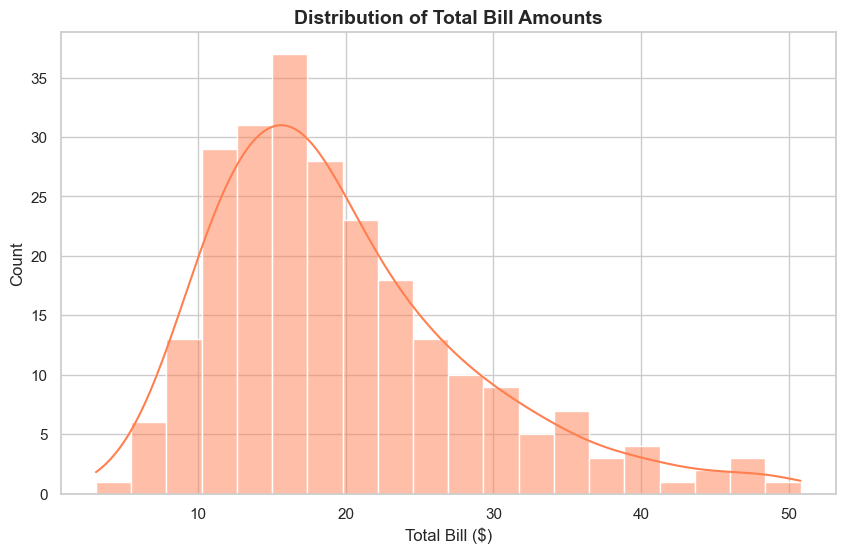

In [2]:
# 📊 histplot: Modern replacement for distplot
plt.figure(figsize=(10, 6))
sns.histplot(data=tips, x="total_bill", bins=20, kde=True, color="coral")
plt.title("Distribution of Total Bill Amounts", fontsize=14, fontweight='bold')
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

# The KDE (Kernel Density Estimate) line shows the smooth probability density

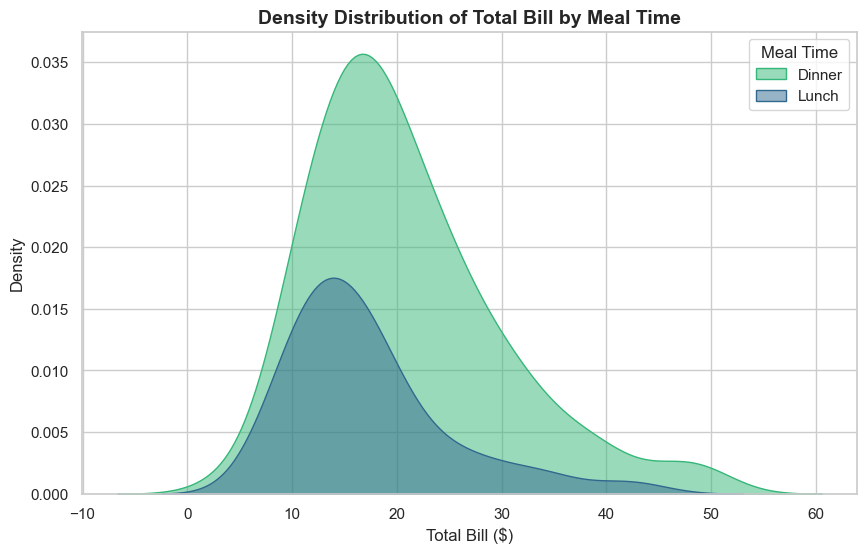

In [3]:
# 📊 kdeplot: Focus on the density curve with multiple distributions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=tips, x="total_bill", hue="time", fill=True, alpha=0.5, palette="viridis")
plt.title("Density Distribution of Total Bill by Meal Time", fontsize=14, fontweight='bold')
plt.xlabel("Total Bill ($)", fontsize=12)
plt.legend(title="Meal Time", labels=["Dinner", "Lunch"])
plt.show()

# This helps compare distributions between categories visually

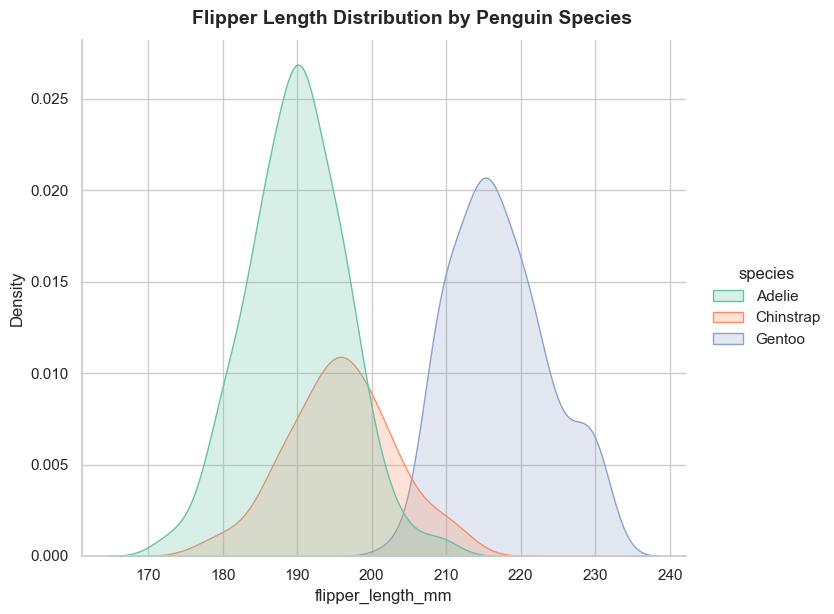

In [4]:
# 📊 displot: Figure-level interface for distributions with facets
g = sns.displot(data=penguins, x="flipper_length_mm", hue="species", 
                kind="kde", fill=True, palette="Set2", height=6, aspect=1.2)
g.fig.suptitle("Flipper Length Distribution by Penguin Species", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# displot creates a FacetGrid, allowing for more complex layouts

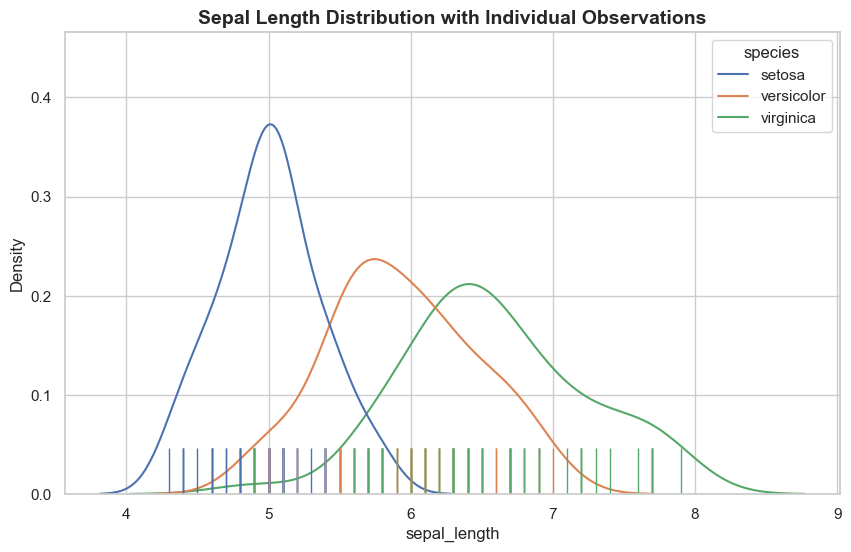

In [5]:
# 📊 rugplot: Show individual observations along the axis
plt.figure(figsize=(10, 6))
sns.kdeplot(data=iris, x="sepal_length", hue="species", palette="deep")
sns.rugplot(data=iris, x="sepal_length", hue="species", palette="deep", height=0.1)
plt.title("Sepal Length Distribution with Individual Observations", fontsize=14, fontweight='bold')
plt.show()

# Rug plots show the actual data points, useful for seeing sample density

## Categorical Plots

Categorical data is common in ML (classes, groups, binary targets). These plots help you:
- Compare distributions across categories
- Identify outliers in each group
- See the spread and central tendency of numeric data by category

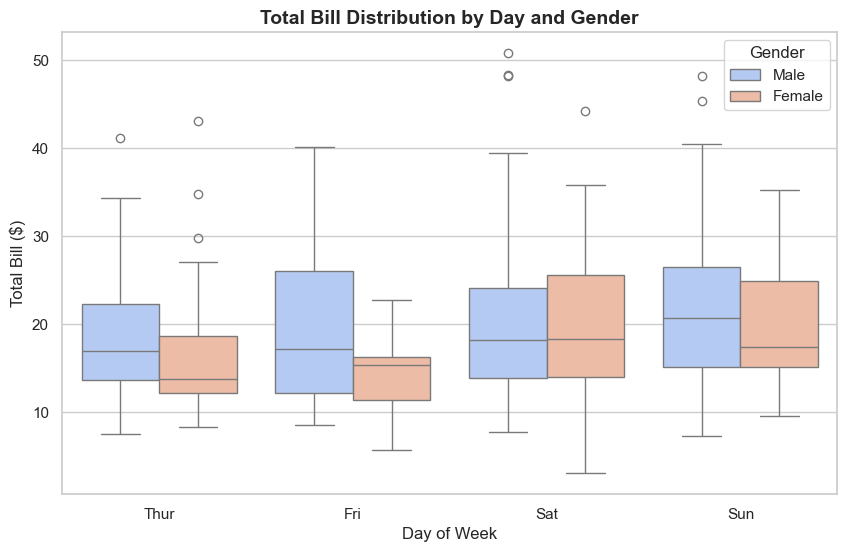

In [6]:
# 📦 boxplot: Classic statistical summary (quartiles, outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(data=tips, x="day", y="total_bill", hue="sex", palette="coolwarm")
plt.title("Total Bill Distribution by Day and Gender", fontsize=14, fontweight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Bill ($)", fontsize=12)
plt.legend(title="Gender")
plt.show()

# Boxplots show median, quartiles, and outliers - great for comparing groups

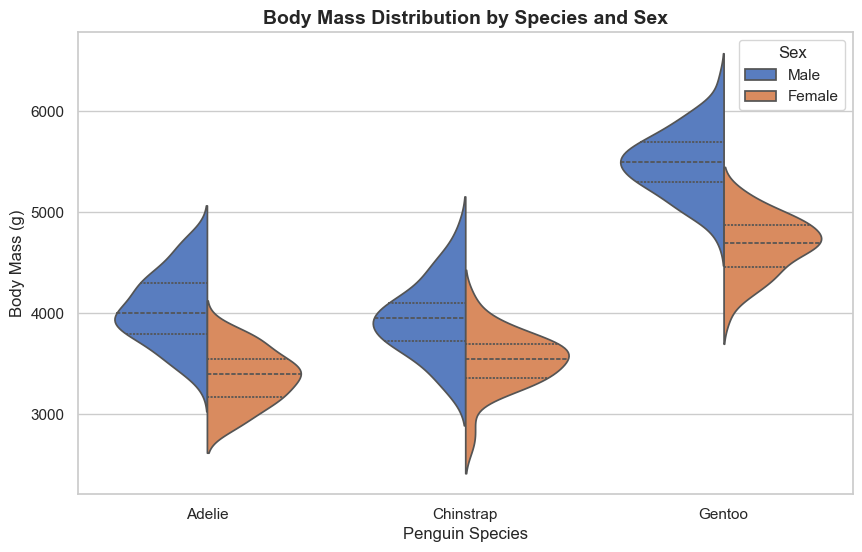

In [7]:
# 🎻 violinplot: Combines boxplot with KDE for richer distribution view
plt.figure(figsize=(10, 6))
sns.violinplot(data=penguins, x="species", y="body_mass_g", hue="sex", 
               split=True, palette="muted", inner="quartile")
plt.title("Body Mass Distribution by Species and Sex", fontsize=14, fontweight='bold')
plt.xlabel("Penguin Species", fontsize=12)
plt.ylabel("Body Mass (g)", fontsize=12)
plt.legend(title="Sex")
plt.show()

# Violin plots show the full distribution shape, not just summary statistics

C:\Users\786\AppData\Local\Temp\ipykernel_7408\812799269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=iris, x="species", y="petal_length", size=6, palette="rocket")


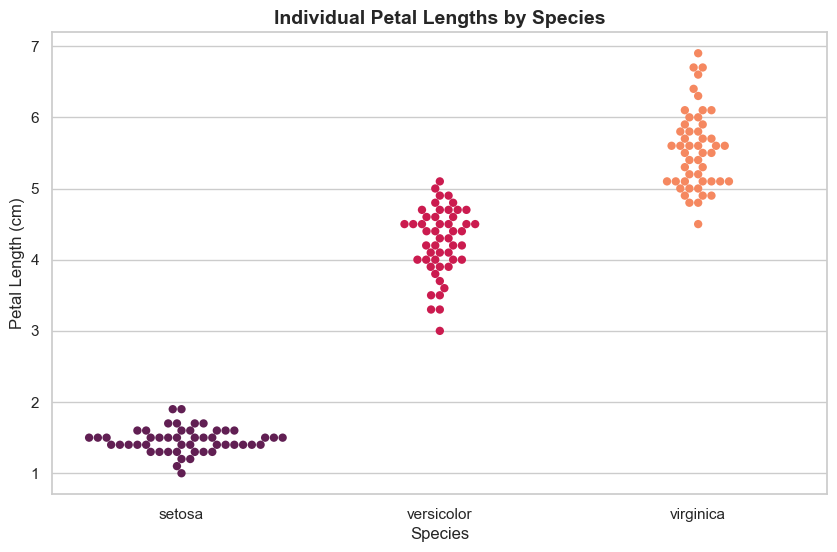

In [8]:
# 🐝 swarmplot: Show all points without overlap (good for smaller datasets)
plt.figure(figsize=(10, 6)) 
sns.swarmplot(data=iris, x="species", y="petal_length", size=6, palette="rocket")
plt.title("Individual Petal Lengths by Species", fontsize=14, fontweight='bold')
plt.xlabel("Species", fontsize=12)
plt.ylabel("Petal Length (cm)", fontsize=12)
plt.show()

# Swarmplots prevent overplotting and show the actual data distribution

## Relationship Plots

Understanding relationships between variables is crucial for:
- Feature engineering (creating interaction terms)
- Detecting multicollinearity
- Visualizing feature-target relationships
- Identifying non-linear patterns

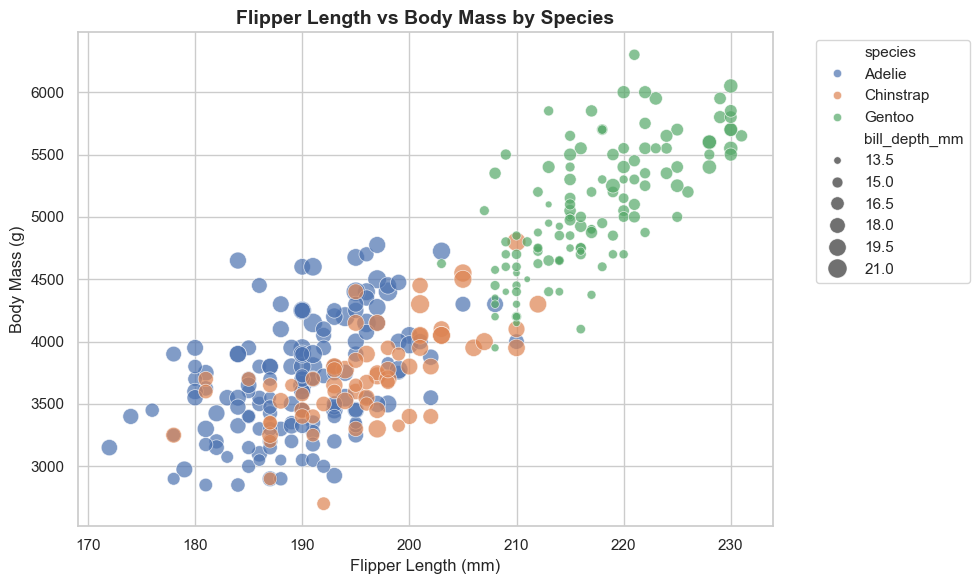

In [9]:
# 🔵 scatterplot: The workhorse of relationship visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", 
                hue="species", size="bill_depth_mm", sizes=(20, 200), 
                palette="deep", alpha=0.7)
plt.title("Flipper Length vs Body Mass by Species", fontsize=14, fontweight='bold')
plt.xlabel("Flipper Length (mm)", fontsize=12)
plt.ylabel("Body Mass (g)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatterplots reveal correlations, clusters, and outliers in 2D space

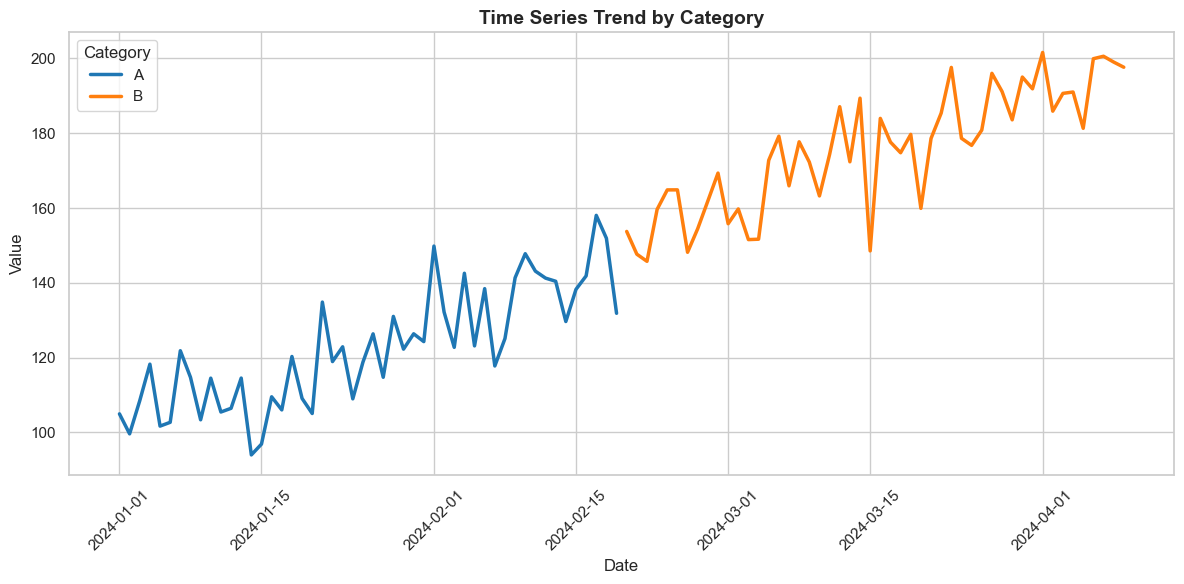

In [10]:
# 📈 lineplot: Best for time series or ordered data
# Create synthetic time series data
np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=100)
trend = np.linspace(100, 200, 100)
noise = np.random.normal(0, 10, 100)
ts_data = pd.DataFrame({
    "date": dates,
    "value": trend + noise,
    "category": ["A"] * 50 + ["B"] * 50
})

plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_data, x="date", y="value", hue="category", palette="tab10", linewidth=2.5)
plt.title("Time Series Trend by Category", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

# Lineplots with confidence intervals are perfect for showing trends over time

## Correlation Analysis

Correlation matrices are essential for:
- Feature selection (remove highly correlated features)
- Understanding feature importance
- Detecting multicollinearity in regression
- Guiding feature engineering decisions

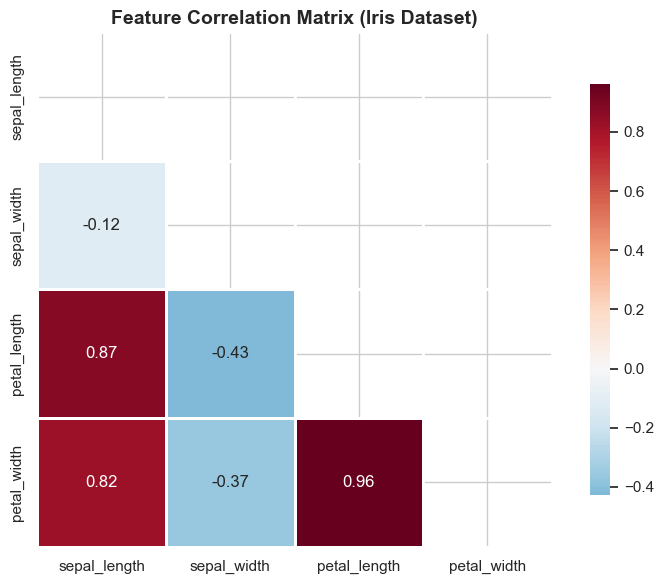

In [11]:
# 🔥 heatmap: Visualize correlation matrices beautifully
# Calculate correlation matrix for numeric features
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
corr_matrix = iris[numeric_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix (Iris Dataset)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Strong correlations (dark red/blue) suggest redundant features

## Pair Plots

Pair plots (scatter matrix) show:
- All pairwise relationships in one view
- Distributions on the diagonal
- Potential clustering by hue variable
- Comprehensive EDA in a single command

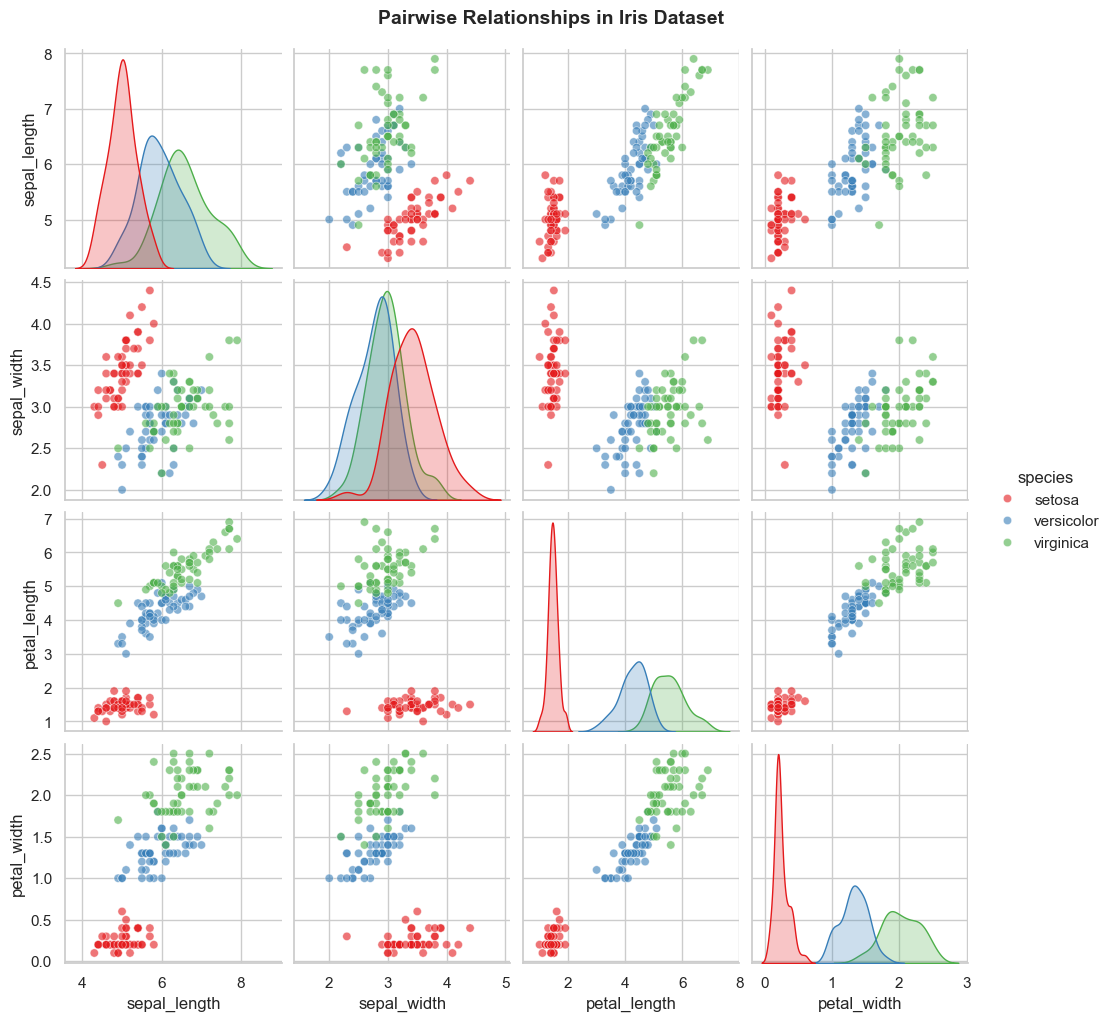

In [12]:
# 🔗 pairplot: The ultimate multivariate visualization
g = sns.pairplot(iris, hue="species", palette="Set1", diag_kind="kde", 
                 height=2.5, aspect=1, plot_kws={'alpha': 0.6})
g.fig.suptitle("Pairwise Relationships in Iris Dataset", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Petal measurements clearly separate the three species - great for classification!

## Joint Plots

Joint plots combine:
- A bivariate scatter or hexbin plot in the center
- Univariate marginal distributions on the sides
- Perfect for deep-diving into specific feature relationships

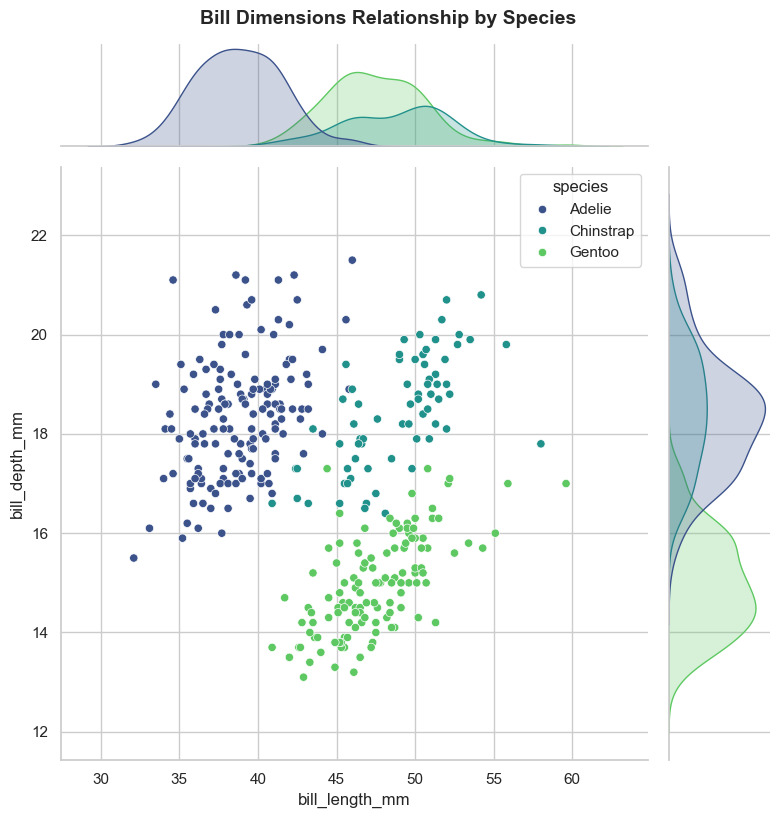

In [13]:
# 🔗 jointplot: Bivariate relationship with marginal distributions
g = sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", 
                  hue="species", kind="scatter", palette="viridis", height=8)
g.fig.suptitle("Bill Dimensions Relationship by Species", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Notice how different species occupy different regions of the plot

## FacetGrid and Categorical Faceting

Faceting allows you to:
- Create small multiples across categories
- Compare patterns across many groups
- Build complex, publication-ready figures

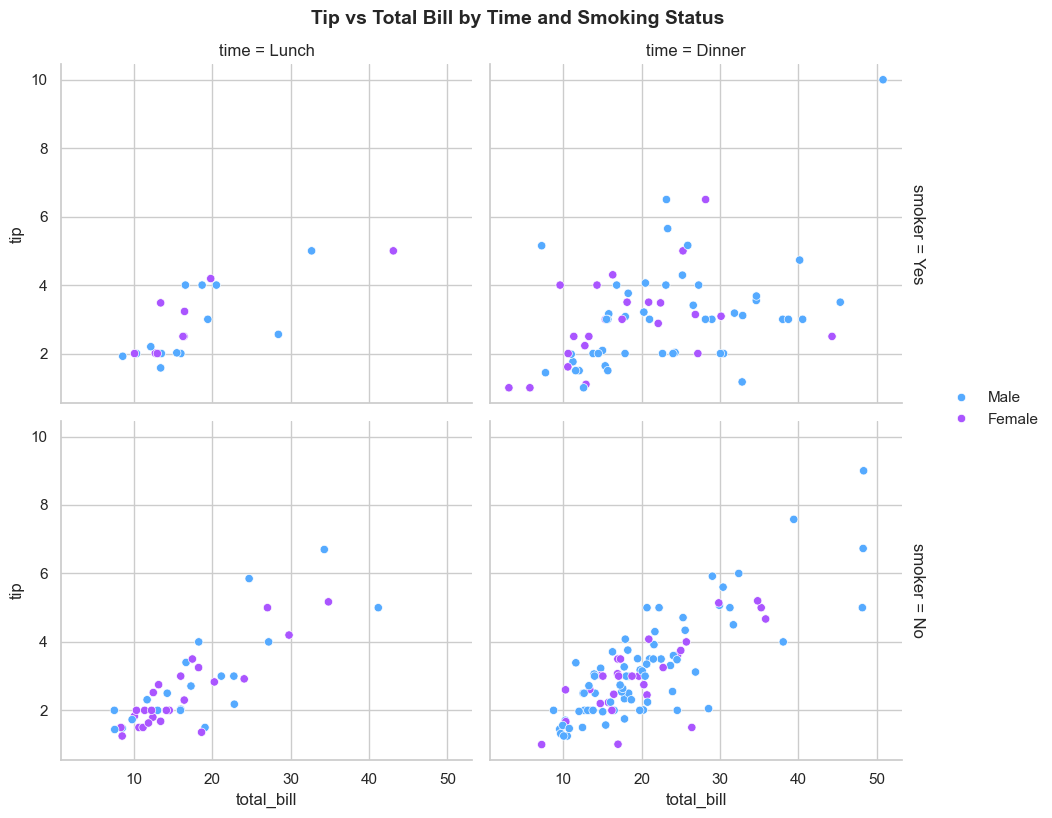

In [14]:
# 🎭 FacetGrid: Create a grid of plots based on categorical variables
g = sns.FacetGrid(tips, col="time", row="smoker", margin_titles=True, height=4, aspect=1.2)
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip", hue="sex", palette="cool")
g.add_legend()
g.fig.suptitle("Tip vs Total Bill by Time and Smoking Status", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Faceting reveals how relationships change across different conditions

C:\Users\786\AppData\Local\Temp\ipykernel_7408\825948293.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=penguins, x="species", y="body_mass_g", col="island",


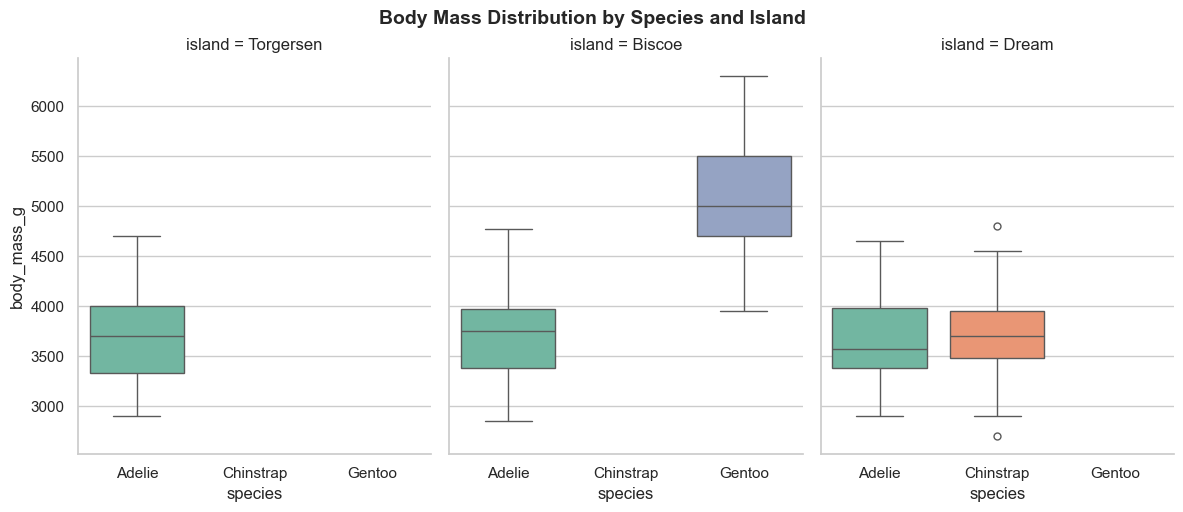

In [15]:
# 📊 catplot: Figure-level interface for categorical plots with faceting
g = sns.catplot(data=penguins, x="species", y="body_mass_g", col="island", 
                kind="box", palette="Set2", height=5, aspect=0.8)
g.fig.suptitle("Body Mass Distribution by Species and Island", y=1.02, fontsize=14, fontweight='bold')
plt.show()

# catplot combines categorical plots with the power of FacetGrid

## Styling and Themes

Professional visualizations require:
- Consistent color palettes
- Appropriate context (paper, talk, poster)
- Clear typography and scaling

C:\Users\786\AppData\Local\Temp\ipykernel_7408\3716126062.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x="day", y="tip", inner="box", palette="rocket")


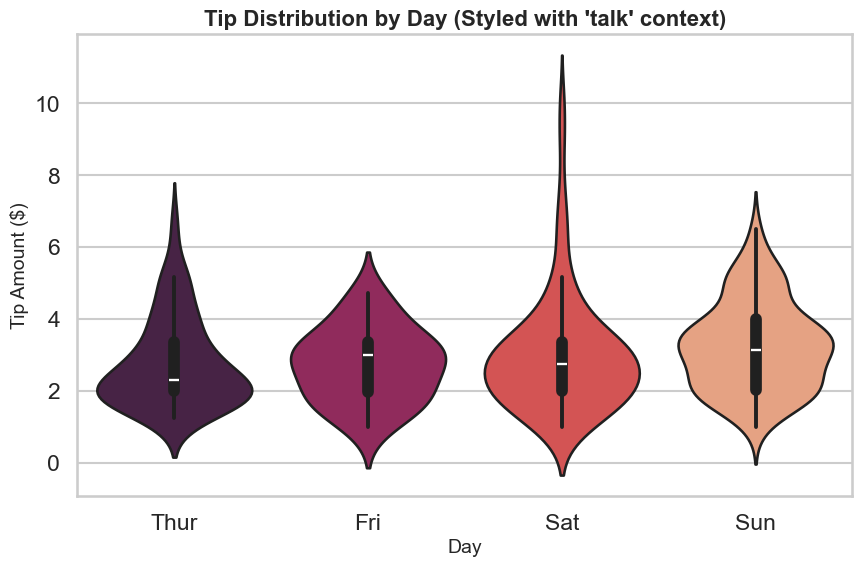

In [16]:
# 🎨 Demonstrate different themes and palettes
themes = ["darkgrid", "whitegrid", "dark", "white", "ticks"]
contexts = ["paper", "notebook", "talk", "poster"]

# Example with different styling
sns.set_theme(style="whitegrid", palette="rocket", context="talk")

plt.figure(figsize=(10, 6))
sns.violinplot(data=tips, x="day", y="tip", inner="box", palette="rocket")
plt.title("Tip Distribution by Day (Styled with 'talk' context)", fontsize=16, fontweight='bold')
plt.xlabel("Day", fontsize=14)
plt.ylabel("Tip Amount ($)", fontsize=14)
plt.show()

# Reset to default after demonstration
sns.set_theme()

## Real AI/ML Examples

Let's apply Seaborn to realistic ML scenarios:
1. Visualizing target variable distribution
2. Checking feature skewness
3. Correlation heatmap for feature selection
4. Feature-target relationships

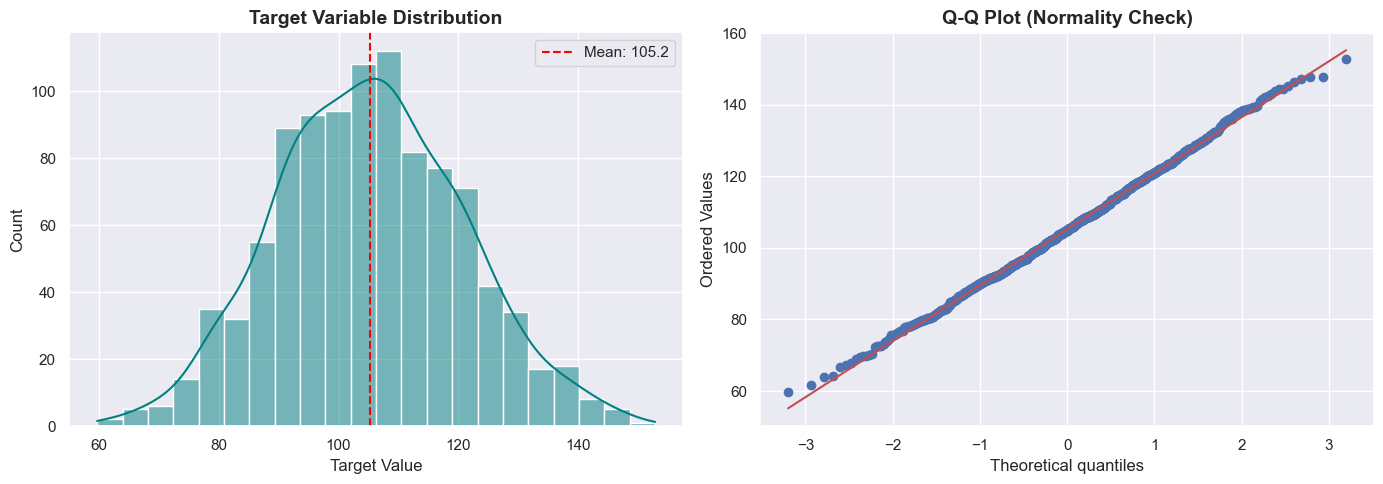

In [17]:
# 🎯 ML Example 1: Create synthetic ML dataset and visualize target distribution
np.random.seed(42)
n_samples = 1000

# Synthetic regression dataset
ml_data = pd.DataFrame({
    'feature_1': np.random.exponential(2, n_samples),  # Skewed feature
    'feature_2': np.random.normal(50, 10, n_samples),  # Normal feature
    'feature_3': np.random.uniform(0, 100, n_samples),  # Uniform feature
    'category': np.random.choice(['A', 'B', 'C'], n_samples),
    'target': np.random.normal(100, 15, n_samples) + np.random.exponential(5, n_samples)
})

# Check target distribution (important for regression problems!)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(ml_data['target'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target Value')
axes[0].axvline(ml_data['target'].mean(), color='red', linestyle='--', label=f'Mean: {ml_data["target"].mean():.1f}')
axes[0].legend()

# Q-Q plot for normality check
from scipy import stats
stats.probplot(ml_data['target'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Right-skewed target might benefit from log transformation!

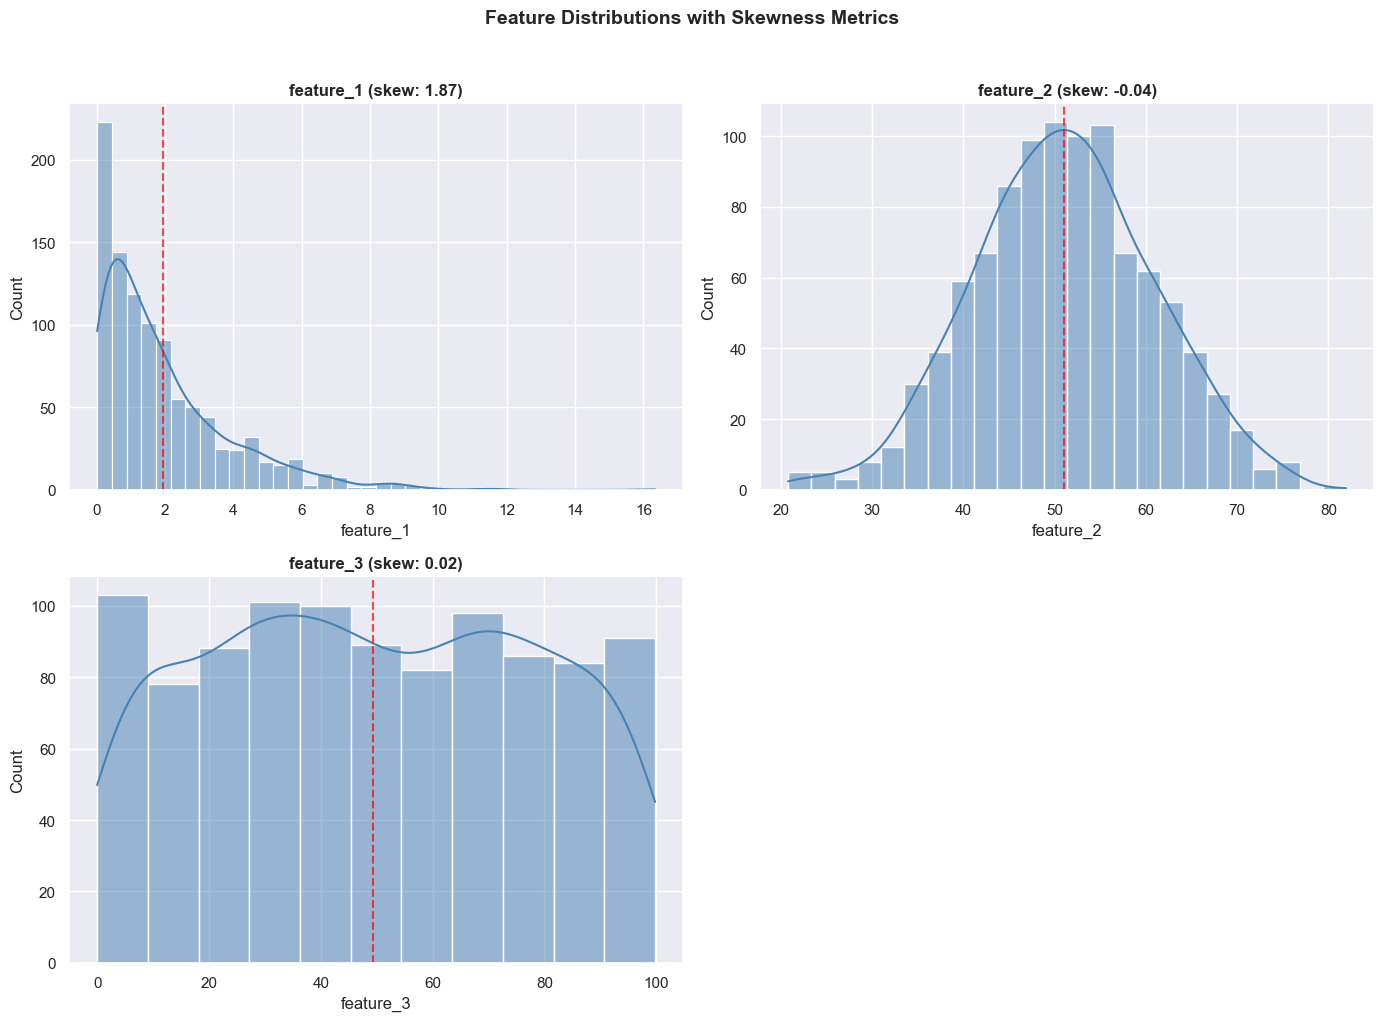

In [18]:
# 🎯 ML Example 2: Feature distributions and skewness detection
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['feature_1', 'feature_2', 'feature_3']

for idx, feature in enumerate(features):
    ax = axes[idx // 2, idx % 2]
    sns.histplot(ml_data[feature], kde=True, ax=ax, color='steelblue')
    skewness = ml_data[feature].skew()
    ax.set_title(f'{feature} (skew: {skewness:.2f})', fontsize=12, fontweight='bold')
    ax.axvline(ml_data[feature].mean(), color='red', linestyle='--', alpha=0.7)

# Remove empty subplot
axes[1, 1].axis('off')

plt.suptitle('Feature Distributions with Skewness Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# feature_1 is highly skewed (exponential) - needs transformation before modeling!

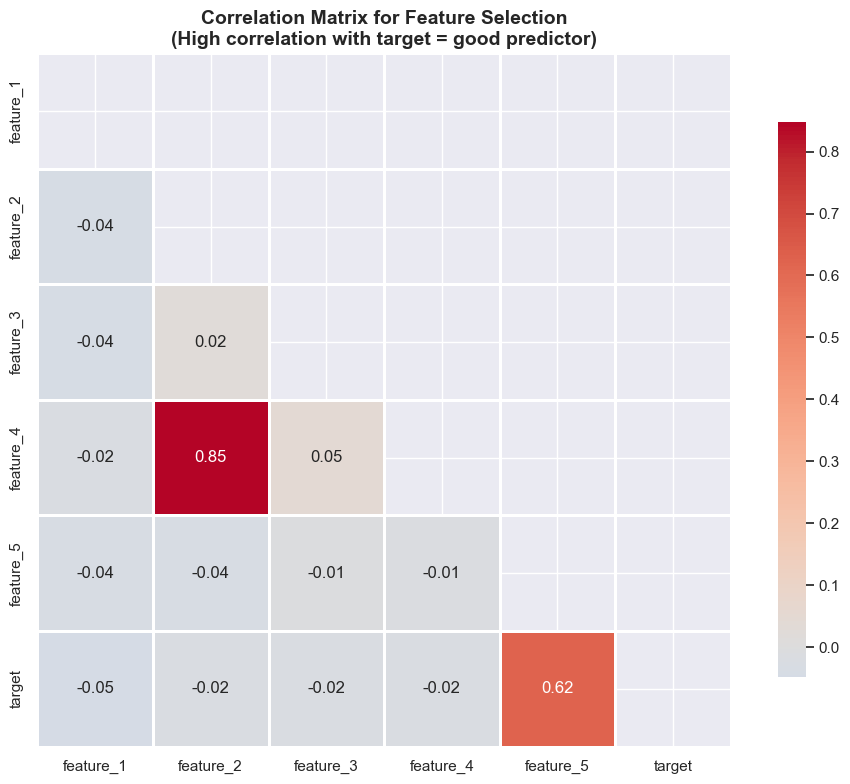

In [19]:
# 🎯 ML Example 3: Correlation heatmap for feature selection
# Add some correlated features
ml_data['feature_4'] = ml_data['feature_2'] * 0.8 + np.random.normal(0, 5, n_samples)  # Correlated with feature_2
ml_data['feature_5'] = ml_data['target'] * 0.5 + np.random.normal(0, 10, n_samples)  # Correlated with target

feature_cols = ['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'target']
corr = ml_data[feature_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix for Feature Selection\n(High correlation with target = good predictor)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# feature_5 highly correlates with target (by design) - strong predictor!
# feature_2 and feature_4 are highly correlated - potential multicollinearity issue!

C:\Users\786\AppData\Local\Temp\ipykernel_7408\1622112094.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ml_data, x='category', y='target', palette='Set2', ax=axes[1,0])


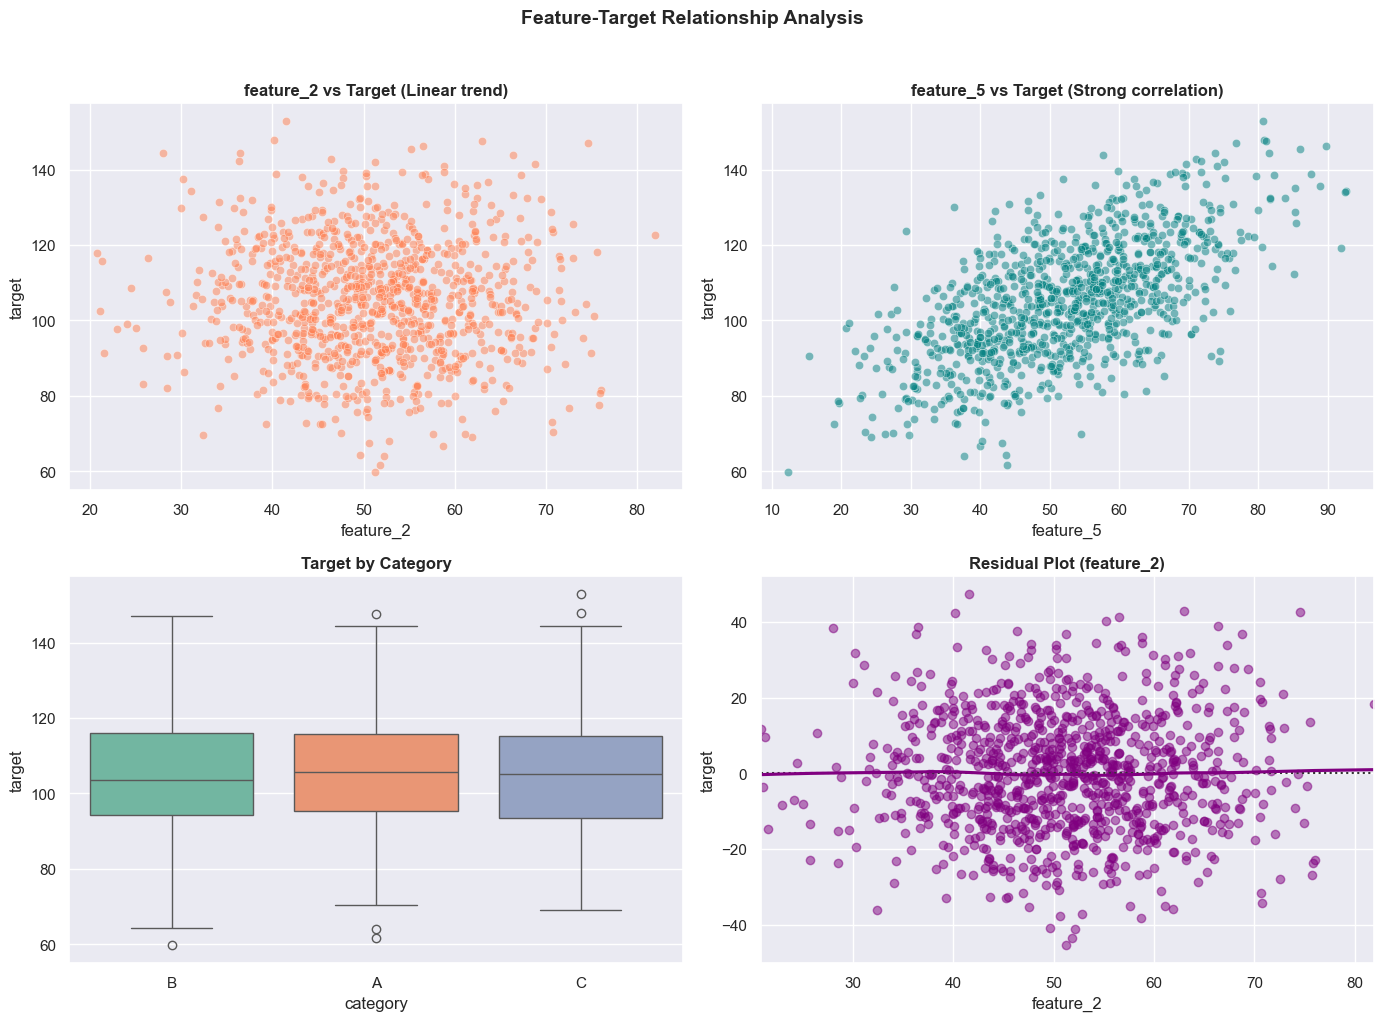

In [20]:
# 🎯 ML Example 4: Feature-target relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plots for numeric features vs target
sns.scatterplot(data=ml_data, x='feature_2', y='target', alpha=0.5, ax=axes[0,0], color='coral')
axes[0,0].set_title('feature_2 vs Target (Linear trend)', fontsize=12, fontweight='bold')

sns.scatterplot(data=ml_data, x='feature_5', y='target', alpha=0.5, ax=axes[0,1], color='teal')
axes[0,1].set_title('feature_5 vs Target (Strong correlation)', fontsize=12, fontweight='bold')

# Box plot for categorical feature
sns.boxplot(data=ml_data, x='category', y='target', palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Target by Category', fontsize=12, fontweight='bold')

# Residual-like plot
sns.residplot(data=ml_data, x='feature_2', y='target', lowess=True, 
              scatter_kws={'alpha': 0.5}, ax=axes[1,1], color='purple')
axes[1,1].set_title('Residual Plot (feature_2)', fontsize=12, fontweight='bold')

plt.suptitle('Feature-Target Relationship Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# These plots help identify which features are predictive and what relationships exist

## 🛠️ Hands-On Exercises

Complete these exercises to master Seaborn for ML visualization. Each exercise builds on the concepts covered above.

### Exercise 1: Distribution Analysis
Create a distribution plot (histplot with KDE) for the 'tip' column in the tips dataset. Add a vertical line showing the mean tip amount.

In [21]:
# your code here


### Exercise 2: Comparative Distributions
Create side-by-side violin plots showing the distribution of 'total_bill' for each 'day' of the week, split by 'smoker' status.

In [22]:
# your code here


### Exercise 3: Correlation Heatmap
Load the 'penguins' dataset, select only the numeric columns, calculate the correlation matrix, and create a heatmap with annotations. Use the 'coolwarm' colormap.

In [23]:
# your code here


### Exercise 4: Pairwise Relationships
Create a pairplot of the iris dataset, but only include 'petal_length' and 'petal_width' columns. Color by species and use the 'husl' palette.

In [24]:
# your code here


### Exercise 5: Feature-Target Scatter
Using the tips dataset, create a scatterplot of 'total_bill' vs 'tip'. Color points by 'time' (Lunch/Dinner) and size them by 'size' (party size). Add a regression line for each time category using `sns.lmplot` in a separate cell or add `sns.regplot` separately.

In [25]:
# your code here


### Exercise 6: Categorical Comparison
Create a boxenplot (letter-value plot) showing 'body_mass_g' distribution across 'species' in the penguins dataset. Add points using stripplot on top with some transparency.

In [26]:
# your code here


### Exercise 7: Faceted Analysis
Use `sns.catplot` to create faceted boxplots of 'tip' by 'day', with separate columns for 'time' and separate rows for 'smoker'.

In [27]:
# your code here


### Exercise 8: Joint Distribution
Create a jointplot of 'bill_length_mm' vs 'bill_depth_mm' from penguins dataset. Use 'hex' kind and color by species.

In [28]:
# your code here


### Exercise 9: Custom Styling
Create any plot from the tips dataset using:
- Style: 'whitegrid'
- Context: 'poster' 
- Palette: 'magma'
- Add a descriptive title with font size 16

Remember to reset to default theme afterward.

In [29]:
# your code here


### Exercise 10: ML Preprocessing Check
Create a function that takes a DataFrame and creates a 2x2 subplot figure showing:
1. Distribution of a specified target column (with KDE)
2. Boxplot of target by a categorical column
3. Scatter of a numeric feature vs target
4. Correlation of top 3 numeric features with target (bar plot)

Test it on the tips dataset with 'tip' as target, 'day' as categorical, and 'total_bill' as numeric feature.

In [30]:
# your code here


### Exercise 11: Advanced Faceting
Create a FacetGrid with 2 rows (sex: Male/Female) and 2 columns (smoker: Yes/No) using the tips dataset. In each subplot, show a scatterplot of total_bill vs tip, colored by time. Add a main title and ensure proper legend placement.

In [31]:
# your code here


## Solutions (check after attempting)

Below are the solutions for each exercise. Try to complete them on your own first!

### ✅ Solution 1: Distribution Analysis

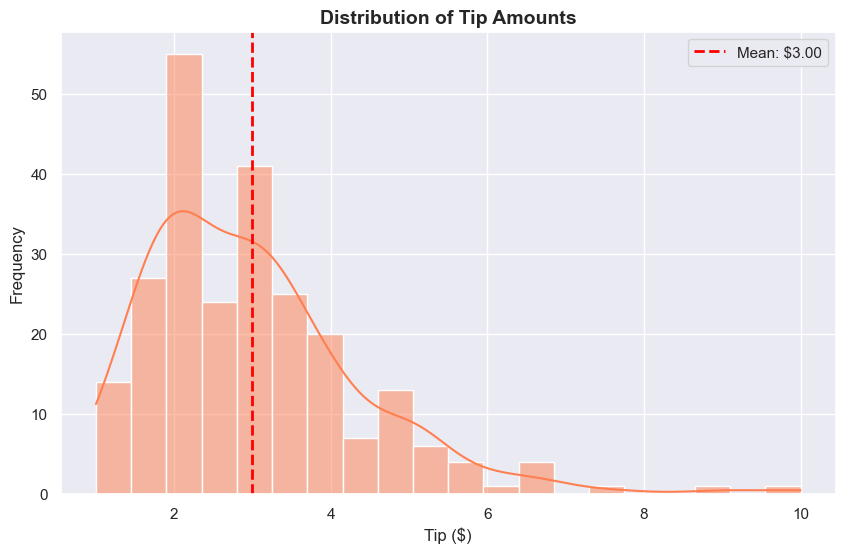

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

plt.figure(figsize=(10, 6))
sns.histplot(tips['tip'], kde=True, color='coral', bins=20)
plt.axvline(tips['tip'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${tips["tip"].mean():.2f}')
plt.title('Distribution of Tip Amounts', fontsize=14, fontweight='bold')
plt.xlabel('Tip ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Expected: Right-skewed distribution showing most tips are between $1-4, with mean around $3

### ✅ Solution 2: Comparative Distributions

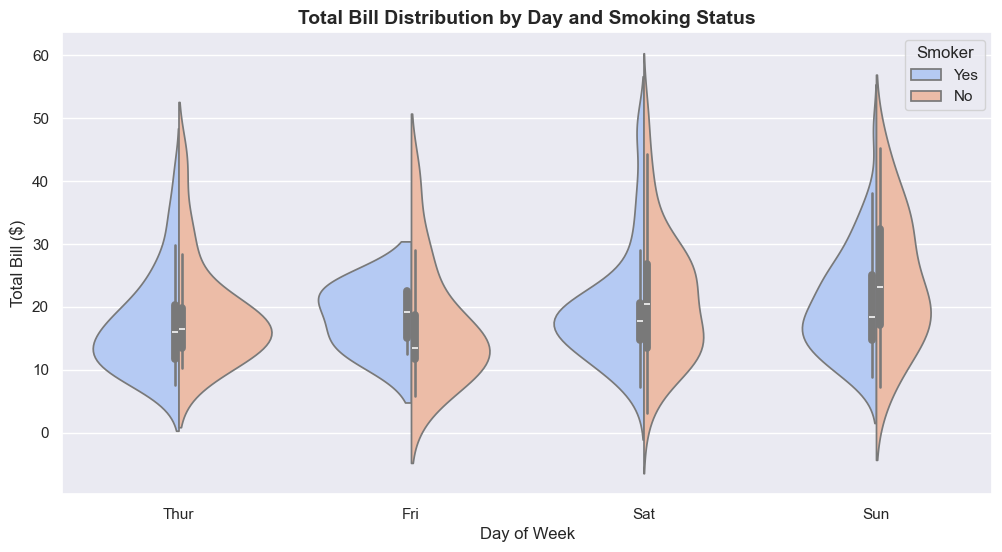

In [33]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=tips, x='day', y='total_bill', hue='smoker', split=True, palette='coolwarm')
plt.title('Total Bill Distribution by Day and Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.legend(title='Smoker')
plt.show()

# Expected: Violin plots showing Saturday/Sunday have higher bills, smokers vs non-smokers patterns vary by day

### ✅ Solution 3: Correlation Heatmap

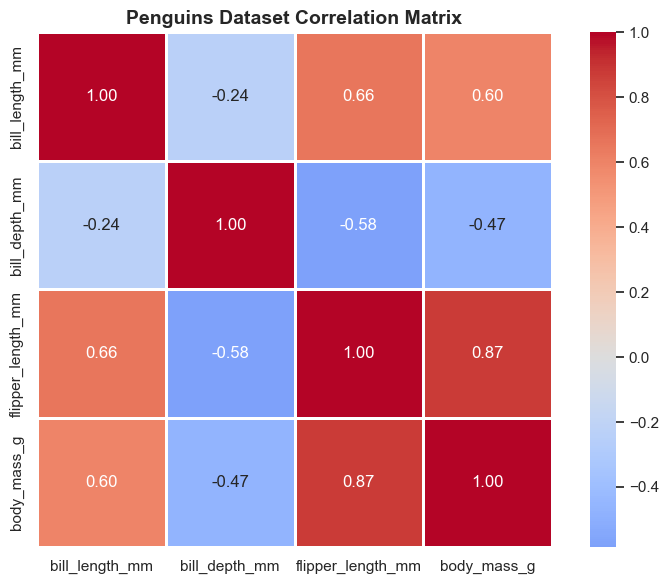

In [34]:
penguins = sns.load_dataset("penguins")

# Select numeric columns and drop NaN
numeric_penguins = penguins.select_dtypes(include=[float, int]).dropna()
corr = numeric_penguins.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Penguins Dataset Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Expected: Strong positive correlations between body_mass_g, flipper_length_mm, and bill_length_mm

### ✅ Solution 4: Pairwise Relationships

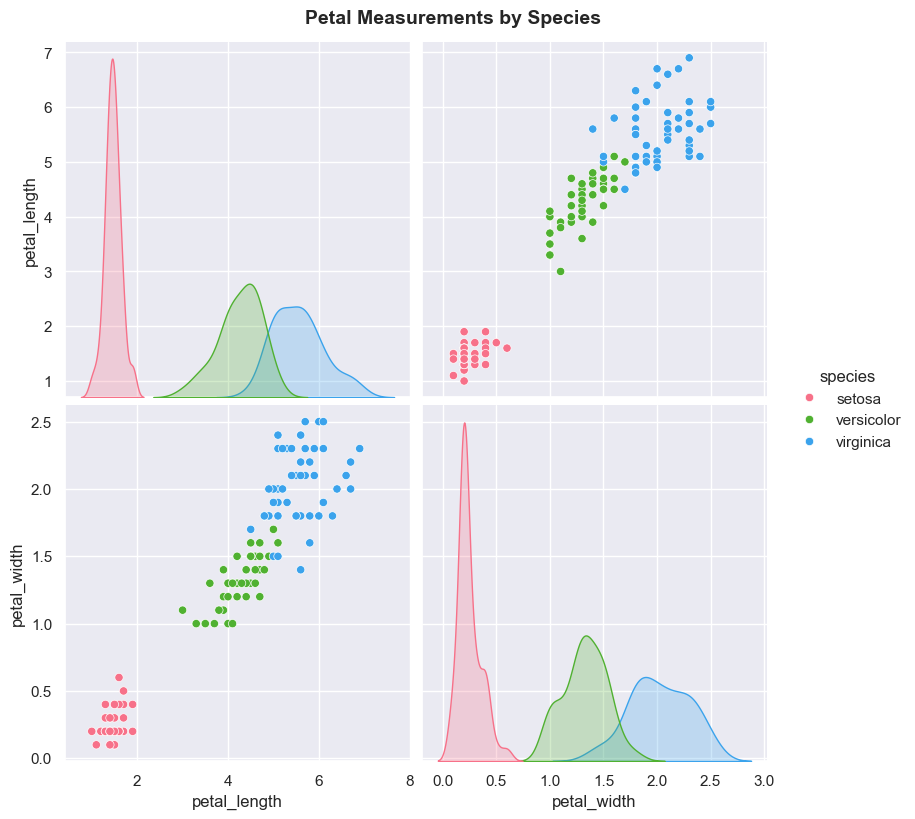

In [35]:
iris = sns.load_dataset("iris")

g = sns.pairplot(iris, vars=['petal_length', 'petal_width'], hue='species', 
                 palette='husl', height=4, diag_kind='kde')
g.fig.suptitle('Petal Measurements by Species', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Expected: Clear separation of species in both scatter and density plots, setosa is distinct

### ✅ Solution 5: Feature-Target Scatter

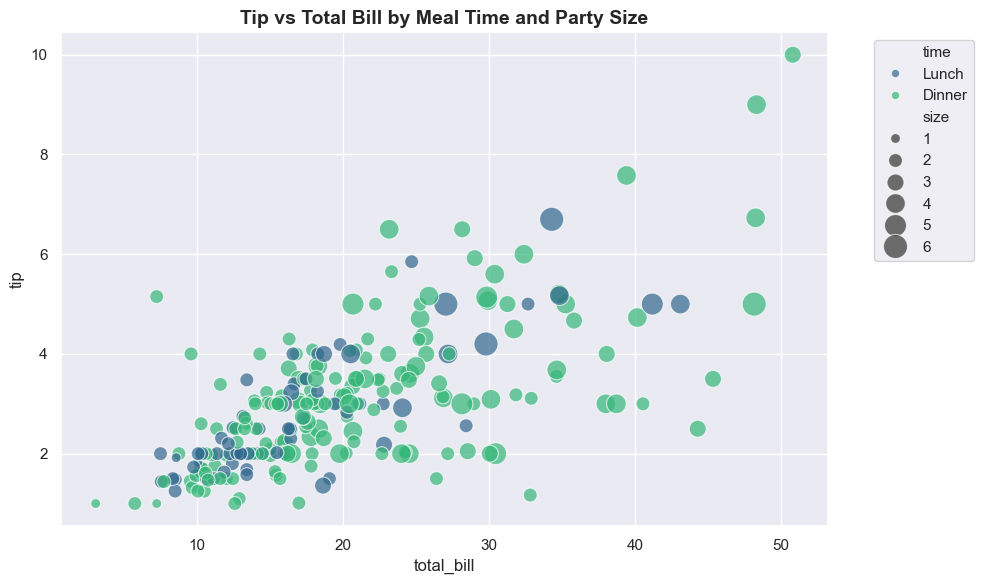

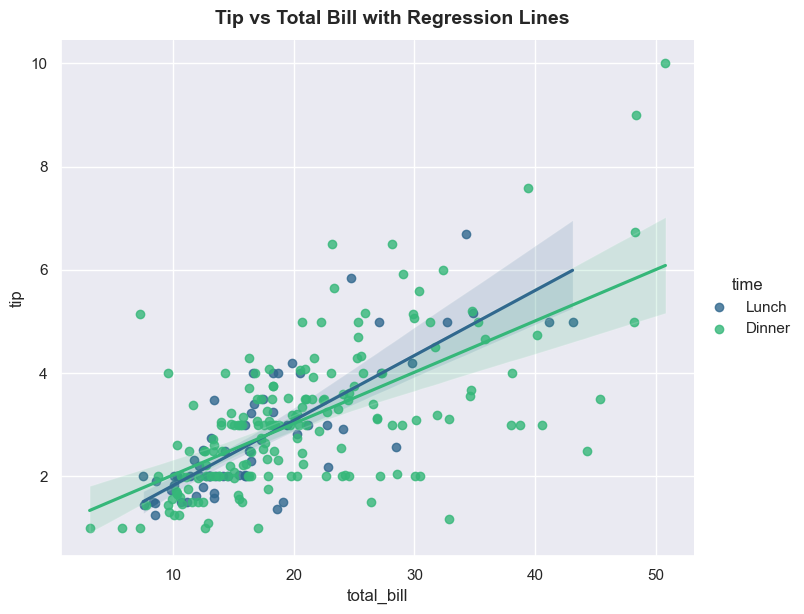

In [36]:
# Scatterplot approach
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', size='size', 
                sizes=(50, 300), palette='viridis', alpha=0.7)
plt.title('Tip vs Total Bill by Meal Time and Party Size', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Alternative: lmplot for regression lines
g = sns.lmplot(data=tips, x='total_bill', y='tip', hue='time', 
               palette='viridis', height=6, aspect=1.2)
g.fig.suptitle('Tip vs Total Bill with Regression Lines', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Expected: Positive linear relationship, dinner tips tend to be higher, larger parties tip more

### ✅ Solution 6: Categorical Comparison

C:\Users\786\AppData\Local\Temp\ipykernel_7408\3654170969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=penguins, x='species', y='body_mass_g', palette='Set2')


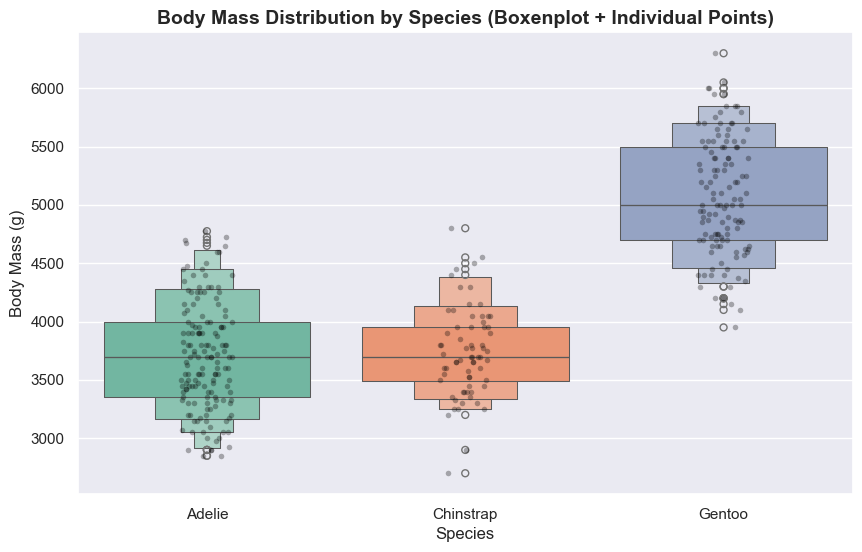

In [37]:
penguins = sns.load_dataset("penguins")

plt.figure(figsize=(10, 6))
sns.boxenplot(data=penguins, x='species', y='body_mass_g', palette='Set2')
sns.stripplot(data=penguins, x='species', y='body_mass_g', color='black', alpha=0.3, size=4)
plt.title('Body Mass Distribution by Species (Boxenplot + Individual Points)', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

# Expected: Gentoo penguins are heaviest, Adelie lightest, boxenplot shows detailed distribution shape

### ✅ Solution 7: Faceted Analysis

C:\Users\786\AppData\Local\Temp\ipykernel_7408\1802827211.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=tips, x='day', y='tip', col='time', row='smoker',


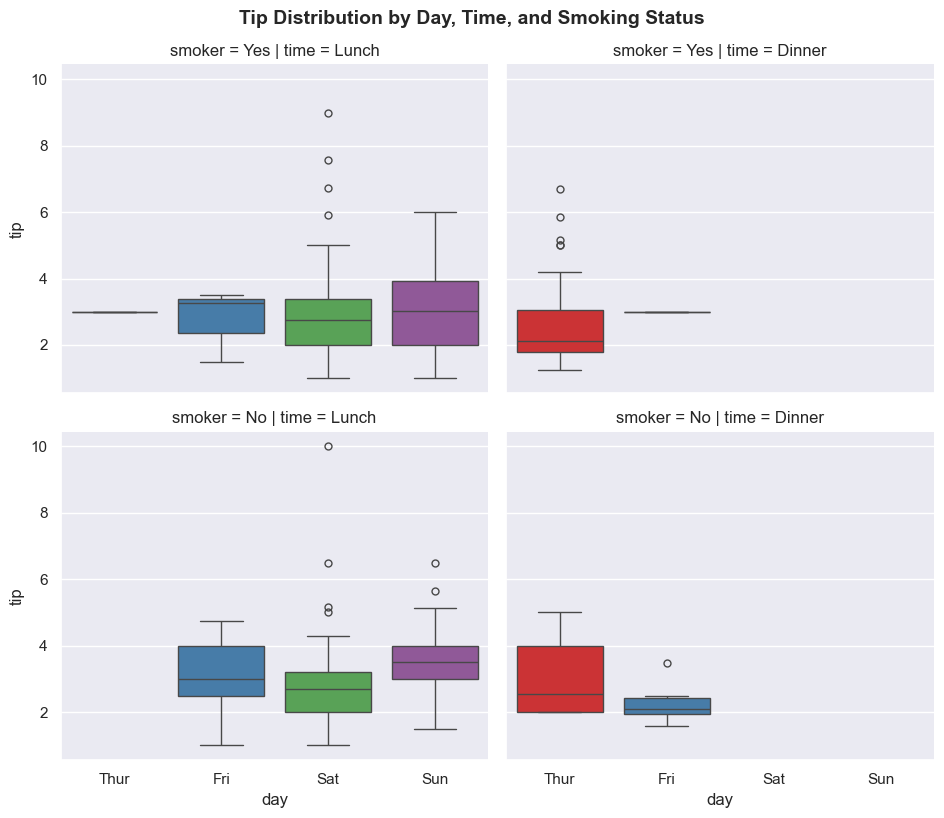

In [38]:
g = sns.catplot(data=tips, x='day', y='tip', col='time', row='smoker', 
                kind='box', palette='Set1', height=4, aspect=1.2)
g.fig.suptitle('Tip Distribution by Day, Time, and Smoking Status', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Expected: 2x2 grid showing tips vary by day, generally higher at dinner, smoker patterns visible

### ✅ Solution 8: Joint Distribution

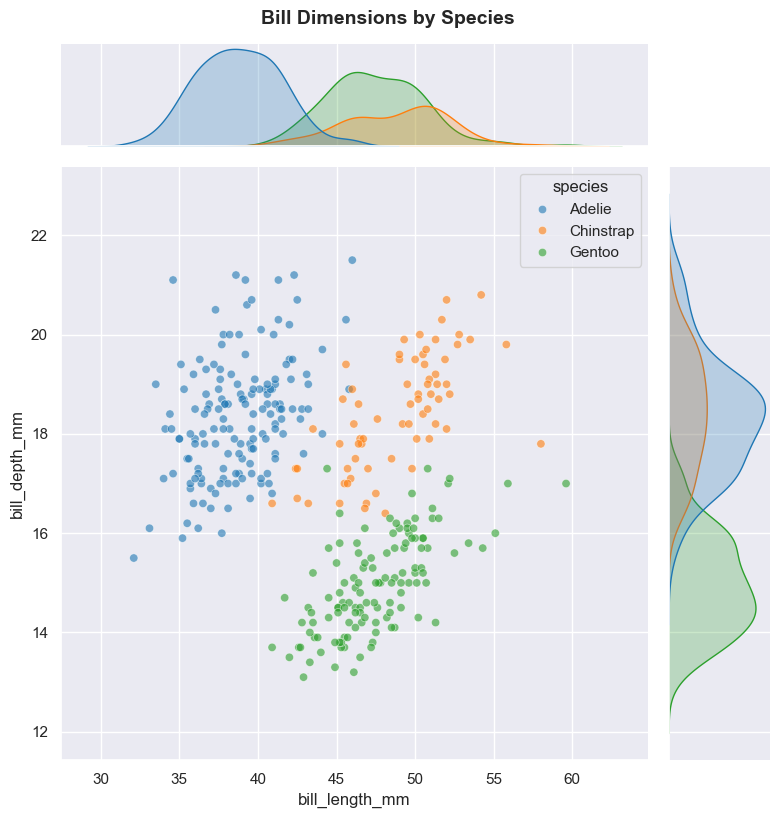

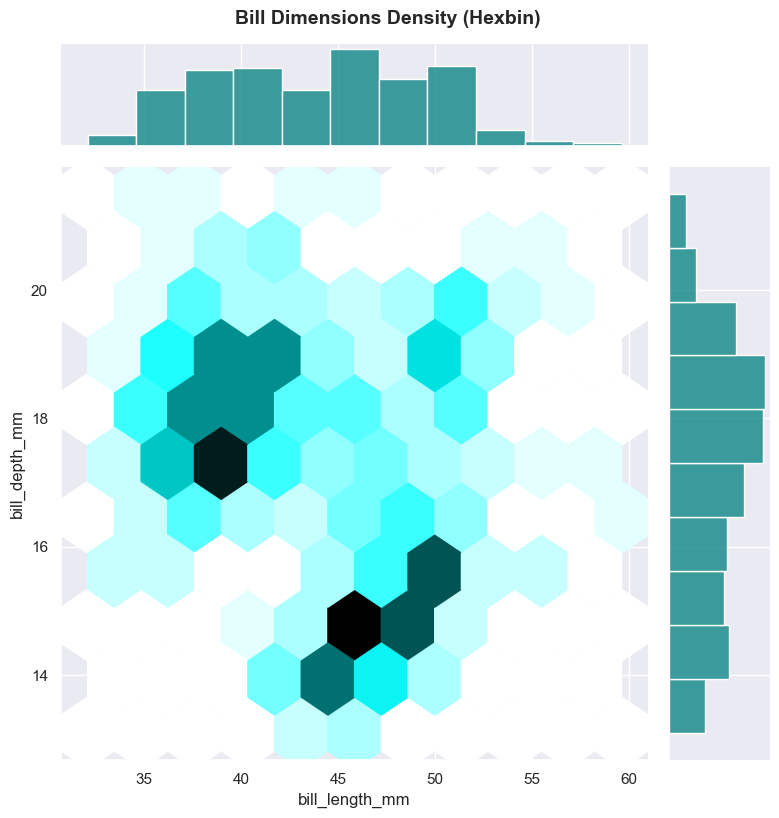

In [39]:
# Note: hex kind doesn't support hue, so we use scatter or kde
g = sns.jointplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', 
                  hue='species', kind='scatter', palette='tab10', height=8, alpha=0.6)
g.fig.suptitle('Bill Dimensions by Species', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Alternative hexbin without hue
g2 = sns.jointplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', 
                   kind='hex', color='teal', height=8)
g2.fig.suptitle('Bill Dimensions Density (Hexbin)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Expected: Clear clustering by species, Gentoo have long shallow bills, Adelie short deep bills

### ✅ Solution 9: Custom Styling

C:\Users\786\AppData\Local\Temp\ipykernel_7408\3233909698.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='time', y='total_bill', inner='quartile', palette='magma')


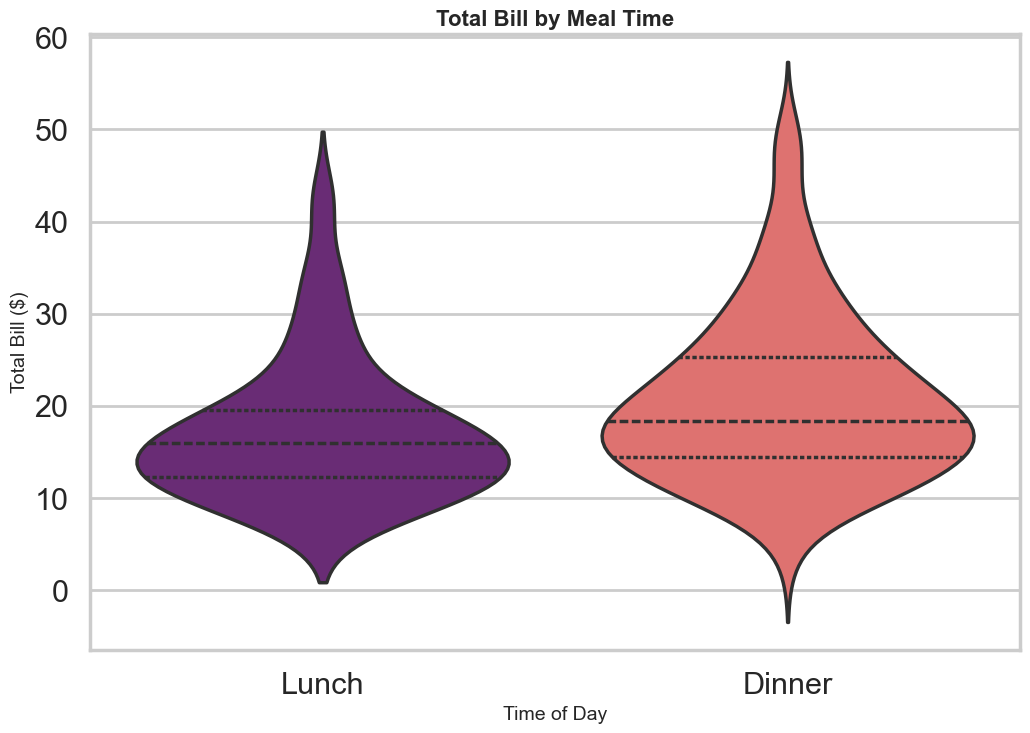

In [40]:
# Set custom theme
sns.set_theme(style='whitegrid', palette='magma', context='poster')

plt.figure(figsize=(12, 8))
sns.violinplot(data=tips, x='time', y='total_bill', inner='quartile', palette='magma')
plt.title('Total Bill by Meal Time', fontsize=16, fontweight='bold')
plt.xlabel('Time of Day', fontsize=14)
plt.ylabel('Total Bill ($)', fontsize=14)
plt.show()

# Reset to default
sns.set_theme()

# Expected: Large, presentation-ready plot with magma color scheme and whitegrid background

### ✅ Solution 10: ML Preprocessing Check

C:\Users\786\AppData\Local\Temp\ipykernel_7408\1855506784.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=cat_col, y=target_col, ax=axes[0,1], palette='Set2')


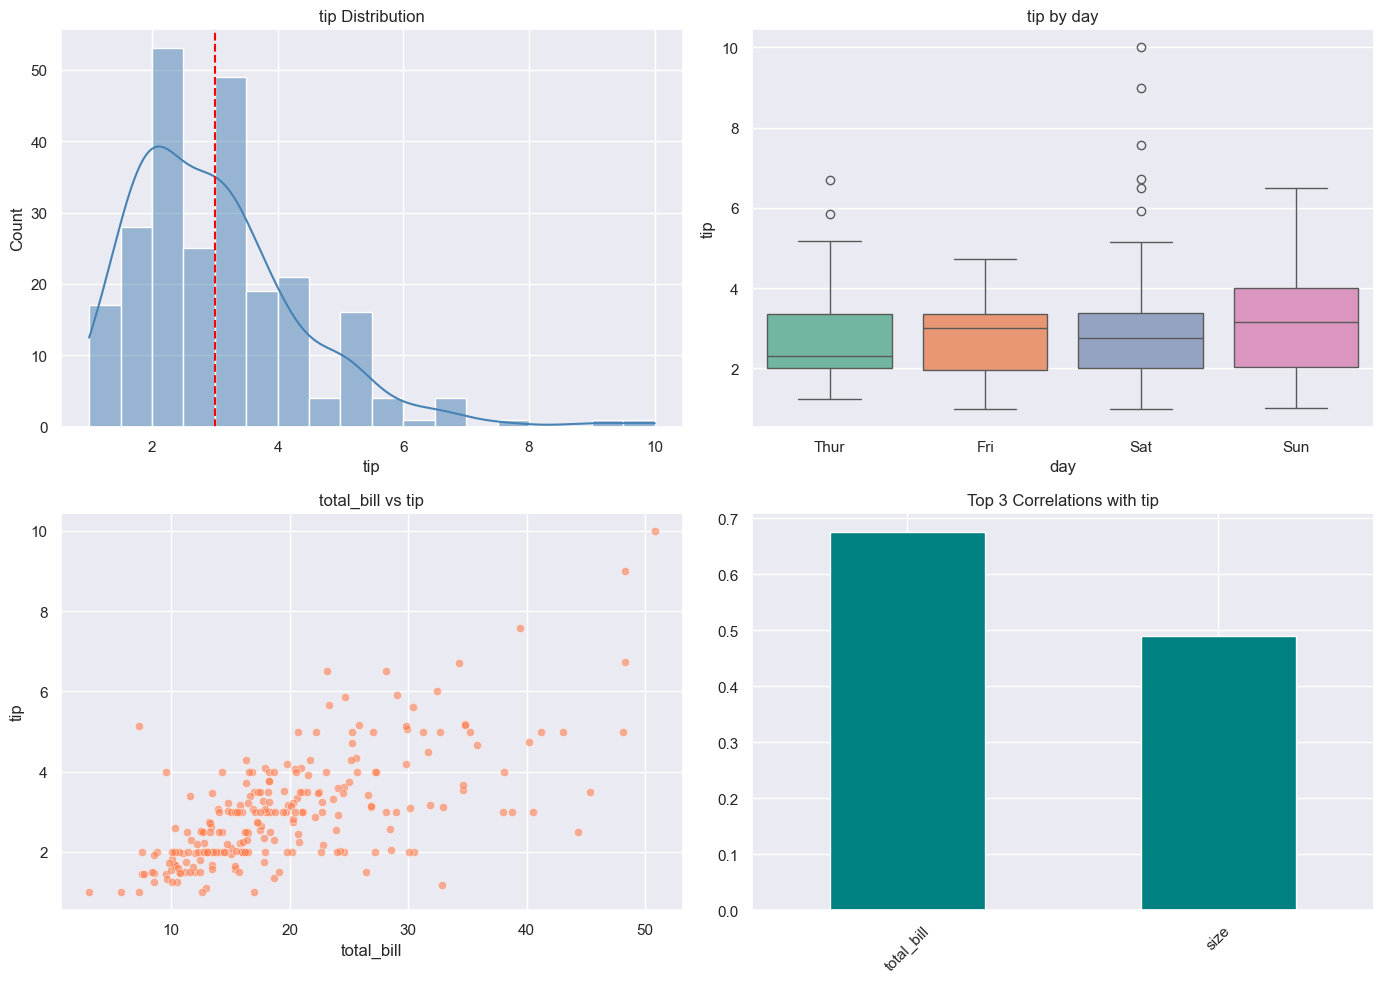

In [41]:
def ml_preprocessing_check(df, target_col, cat_col, num_col):
    """Create a comprehensive EDA subplot for ML preprocessing."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Target distribution
    sns.histplot(df[target_col], kde=True, ax=axes[0,0], color='steelblue')
    axes[0,0].set_title(f'{target_col} Distribution')
    axes[0,0].axvline(df[target_col].mean(), color='red', linestyle='--')
    
    # 2. Target by category
    sns.boxplot(data=df, x=cat_col, y=target_col, ax=axes[0,1], palette='Set2')
    axes[0,1].set_title(f'{target_col} by {cat_col}')
    
    # 3. Numeric vs Target
    sns.scatterplot(data=df, x=num_col, y=target_col, ax=axes[1,0], alpha=0.6, color='coral')
    axes[1,0].set_title(f'{num_col} vs {target_col}')
    
    # 4. Top correlations with target
    numeric_cols = df.select_dtypes(include=[float, int]).columns
    corr_with_target = df[numeric_cols].corr()[target_col].drop(target_col).abs().sort_values(ascending=False).head(3)
    corr_with_target.plot(kind='bar', ax=axes[1,1], color='teal')
    axes[1,1].set_title(f'Top 3 Correlations with {target_col}')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Test the function
ml_preprocessing_check(tips, 'tip', 'day', 'total_bill')

# Expected: 4-panel figure showing tip distribution, tips by day, total_bill vs tip scatter, 
# and correlation bar chart (total_bill will be highest)

### ✅ Solution 11: Advanced Faceting

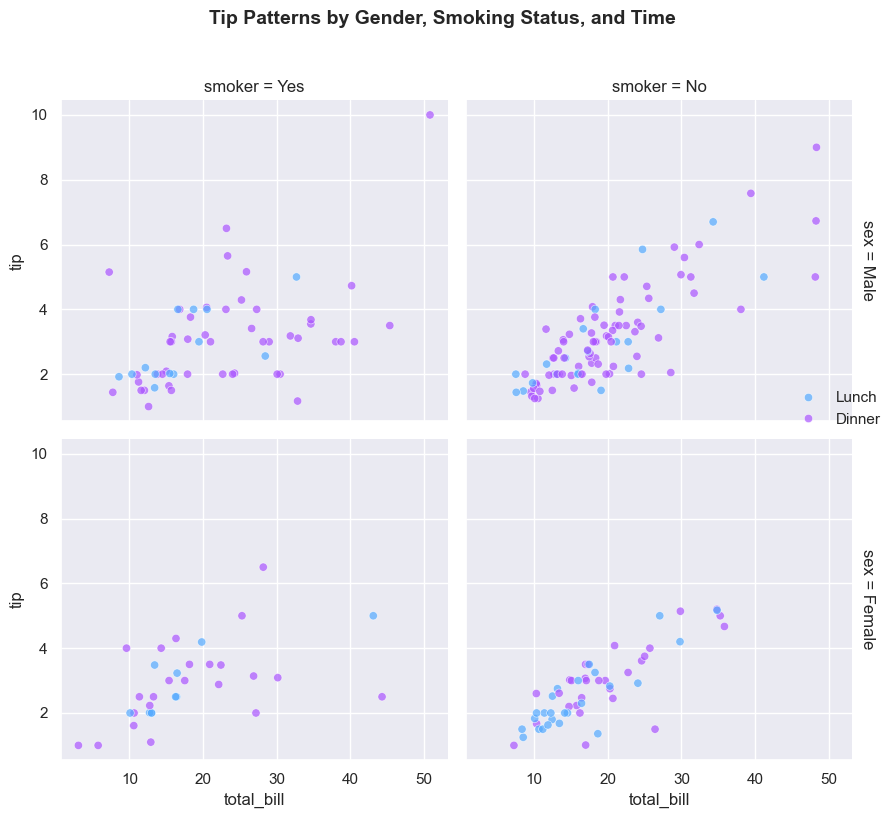

In [42]:
g = sns.FacetGrid(tips, row='sex', col='smoker', margin_titles=True, height=4, aspect=1)
g.map_dataframe(sns.scatterplot, x='total_bill', y='tip', hue='time', palette='cool', alpha=0.7)
g.add_legend()
g.fig.suptitle('Tip Patterns by Gender, Smoking Status, and Time', y=1.02, fontsize=14, fontweight='bold')

# Adjust subplot spacing
g.fig.tight_layout()
plt.show()

# Expected: 2x2 grid with Male/Female rows, Smoker Yes/No columns, 
# scatterplots colored by Lunch/Dinner showing different tipping patterns across demographics